# Experiment 1: Quick vs Full Run – Visual Comparison

Comparing the **Quick** (early-cancelled) and **Full** (complete) cluster runs side by side.

- Quick run finished only a subset of datasets before cancellation.
- Full run covers more datasets and includes the same method suite.
- The next cell summarizes which datasets were evaluated in each run.

**Methods assessed:** Med3-TabPFN • Med3-LoCalPFN • DenseNet121-3D • ViT-3D

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
sns.set_palette('Set2')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 11

RUN_COLORS = {'Quick': '#FF6B6B', 'Full': '#4ECDC4'}
METHOD_COLORS = {
    'tabpfn': '#E74C3C',
    'localpfn': '#3498DB',
    'densenet121_3d': '#2ECC71',
    'vit3d': '#F39C12'
}

In [3]:
import pandas as pd
from pathlib import Path

# Load CSVs
repo_root = Path.cwd().parent.parent
quick_csv = repo_root / 'results_from_cluster' / 'combined_benchmarks_summary.csv'
full_csv = repo_root / 'results' / 'experiment1' / 'combined_benchmarks_summary.csv'

df_quick = pd.read_csv(quick_csv)
df_full = pd.read_csv(full_csv)

# Identify coverage
quick_done = set(df_quick[df_quick['accuracy'].notna()]['dataset'])
full_done = set(df_full[df_full['accuracy'].notna()]['dataset'])

coverage = pd.DataFrame({
    'Dataset': sorted(quick_done | full_done)
})
coverage['Quick Run'] = coverage['Dataset'].apply(lambda d: '✅' if d in quick_done else '—')
coverage['Full Run'] = coverage['Dataset'].apply(lambda d: '✅' if d in full_done else '—')
coverage['Status'] = coverage.apply(
    lambda row: 'Both' if row['Quick Run'] == '✅' and row['Full Run'] == '✅'
    else ('Quick only' if row['Quick Run'] == '✅' else 'Full only'),
    axis=1
)

coverage.set_index('Dataset')

,Quick Run,Full Run,Status
Dataset,,,
crlm,✅,✅,Both
desmoid,—,✅,Full only
gist,✅,✅,Both
lipo,✅,✅,Both
liver,—,✅,Full only
melanoma,—,✅,Full only


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
sns.set_palette('Set2')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

RUN_COLORS = {'Quick': '#FF6B6B', 'Full': '#4ECDC4'}
METHOD_COLORS = {'tabpfn': '#E74C3C', 'localpfn': '#3498DB', 'densenet121_3d': '#2ECC71', 'vit3d': '#F39C12'}

repo_root = Path.cwd().parent.parent
df_quick = pd.read_csv(repo_root / 'results_from_cluster' / 'combined_benchmarks_summary.csv')
df_full = pd.read_csv(repo_root / 'results' / 'experiment1' / 'combined_benchmarks_summary.csv')

df_quick['run'] = 'Quick'
df_full['run'] = 'Full'
df_quick_valid = df_quick[df_quick['accuracy'].notna()]
df_full_valid = df_full[df_full['accuracy'].notna()]
df_combined = pd.concat([df_quick_valid, df_full_valid])

print(f"📊 Quick: {len(df_quick_valid)} results | Full: {len(df_full_valid)} results")

📊 Quick: 11 results | Full: 20 results


## 1. Overall Performance Comparison

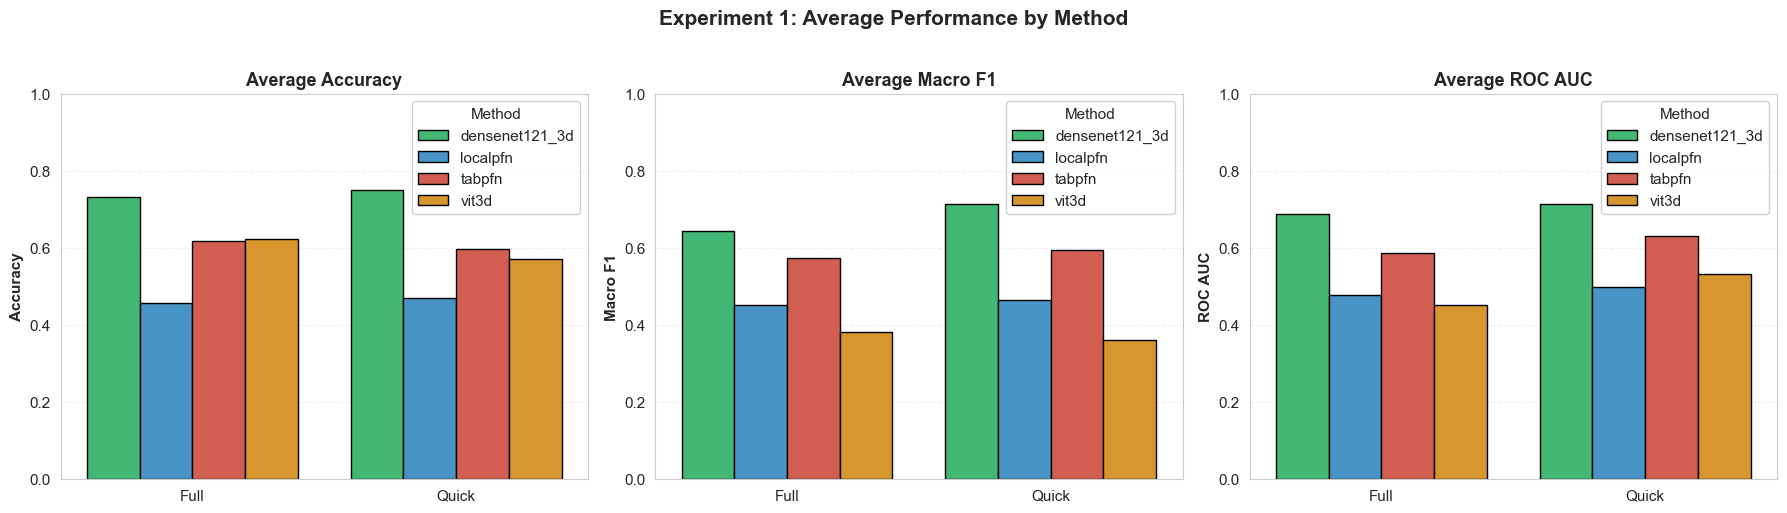

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (metric, name) in zip(axes, [('accuracy', 'Accuracy'), ('macro_f1', 'Macro F1'), ('roc_auc', 'ROC AUC')]):
    avg_data = (
        df_combined.groupby(['run', 'method'])[metric]
        .mean()
        .reset_index()
    )

    sns.barplot(
        data=avg_data,
        x='run',
        y=metric,
        hue='method',
        palette=METHOD_COLORS,
        ax=ax,
        edgecolor='black'
    )

    ax.set_ylabel(name, fontweight='bold')
    ax.set_title(f'Average {name}', fontweight='bold', fontsize=13)
    ax.set_xlabel('')
    ax.set_ylim(0, 1)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.legend(title='Method', framealpha=0.9)

plt.suptitle('Experiment 1: Average Performance by Method', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 2. ROC AUC Heatmaps

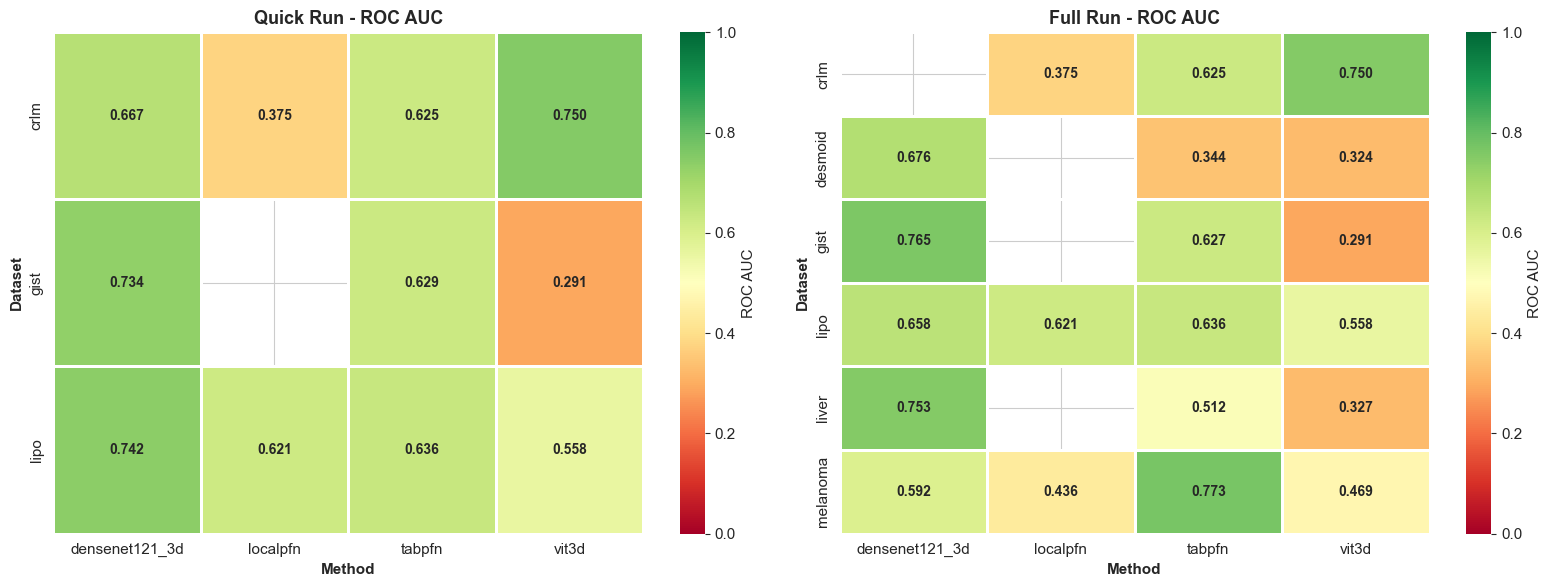

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (df_data, title) in zip(axes, [(df_quick_valid, 'Quick Run'), (df_full_valid, 'Full Run')]):
    pivot = df_data.pivot_table(index='dataset', columns='method', values='roc_auc')
    sns.heatmap(pivot, annot=True, fmt='.3f', cmap='RdYlGn', vmin=0, vmax=1, ax=ax,
                linewidths=2, linecolor='white', cbar_kws={'label': 'ROC AUC'},
                annot_kws={'fontsize': 10, 'fontweight': 'bold'})
    ax.set_title(f'{title} - ROC AUC', fontweight='bold', fontsize=13)
    ax.set_xlabel('Method', fontweight='bold')
    ax.set_ylabel('Dataset', fontweight='bold')

plt.tight_layout()
plt.show()

## 3. Direct Comparison Scatter

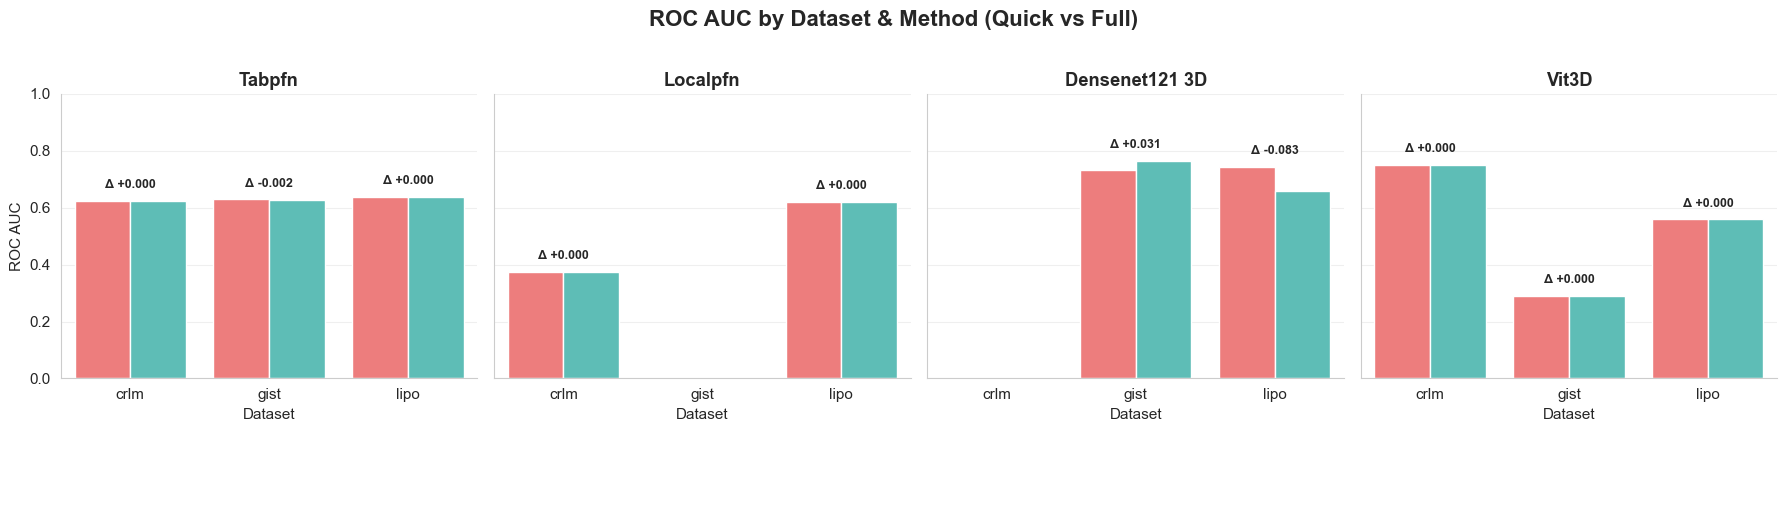


✅ 10 common dataset–method pairs compared


In [7]:
df_comp = pd.merge(
    df_quick_valid[['dataset', 'method', 'roc_auc']].rename(columns={'roc_auc': 'roc_auc_quick'}),
    df_full_valid[['dataset', 'method', 'roc_auc']].rename(columns={'roc_auc': 'roc_auc_full'}),
    on=['dataset', 'method']
)

if len(df_comp) > 0:
    long_comp = df_comp.melt(
        id_vars=['dataset', 'method'],
        value_vars=['roc_auc_quick', 'roc_auc_full'],
        var_name='run_tag',
        value_name='roc_auc'
    )
    long_comp['run'] = long_comp['run_tag'].map({
        'roc_auc_quick': 'Quick run',
        'roc_auc_full': 'Full run'
    })

    dataset_order = sorted(long_comp['dataset'].unique())
    method_order = ['tabpfn', 'localpfn', 'densenet121_3d', 'vit3d']

    g = sns.catplot(
        data=long_comp,
        x='dataset', y='roc_auc', hue='run', col='method',
        kind='bar', palette=[RUN_COLORS['Quick'], RUN_COLORS['Full']],
        order=dataset_order,
        col_order=[m for m in method_order if m in long_comp['method'].unique()],
        height=4.2, aspect=1.0
    )

    for ax, method in zip(g.axes.flat, g.col_names):
        ax.set_title(method.replace('_', ' ').title(), fontweight='bold')
        ax.set_xlabel('Dataset')
        ax.set_ylabel('ROC AUC')
        ax.set_ylim(0, 1)
        ax.grid(axis='y', alpha=0.3)

        subset = df_comp[df_comp['method'] == method]
        for idx, row in subset.iterrows():
            quick_val = row['roc_auc_quick']
            full_val = row['roc_auc_full']
            diff = full_val - quick_val
            x_pos = dataset_order.index(row['dataset'])
            ax.text(
                x_pos, max(quick_val, full_val) + 0.035,
                f"Δ {diff:+.3f}", ha='center', va='bottom', fontsize=9, fontweight='bold'
            )

    g.fig.suptitle('ROC AUC by Dataset & Method (Quick vs Full)', fontsize=16, fontweight='bold', y=1.02)
    g._legend.set_title('Run')
    for text in g._legend.texts:
        text.set_fontsize(10)
    g._legend.get_texts()[0].set_text('Quick run')
    g._legend.get_texts()[1].set_text('Full run')
    g._legend.set_bbox_to_anchor((0.5, -0.1))
    g._legend.set_title('Run')
    g._legend.set_frame_on(True)
    g._legend.get_frame().set_edgecolor('black')

    plt.tight_layout()
    plt.show()

    print(f"\n✅ {len(df_comp)} common dataset–method pairs compared")
else:
    print("⚠️ No common datasets")

## 4. Numeric Summaries

In [8]:
# Table 1: metrics per dataset & method (Quick vs Full)
metrics_cols = ['accuracy', 'macro_f1', 'roc_auc']

combined_runs = pd.concat([
    df_quick_valid.assign(run='Quick'),
    df_full_valid.assign(run='Full')
])

summary_table = (
    combined_runs
    .pivot_table(
        index=['dataset', 'method'],
        columns='run',
        values=metrics_cols
    )
    .sort_index()
)

dataset_summary = (
    combined_runs.groupby(['dataset', 'run'])[metrics_cols]
    .mean()
    .unstack('run')
    .round(3)
)

print('Average metrics by dataset (rows) and run (columns):')
display(dataset_summary)

print('\nPer-dataset breakdown (methods as rows):')
for dataset in sorted(summary_table.index.get_level_values('dataset').unique()):
    print(f"\nDataset: {dataset}")
    dataset_table = summary_table.loc[dataset].round(3)
    dataset_table.columns = [f"{metric} ({run})" for metric, run in dataset_table.columns]
    display(dataset_table)

Average metrics by dataset (rows) and run (columns):


accuracy        macro_f1        roc_auc       
run          Full  Quick     Full  Quick    Full  Quick
dataset                                                
crlm        0.562  0.609    0.482  0.545   0.583  0.604
desmoid     0.732    NaN    0.517    NaN   0.448    NaN
gist        0.573  0.580    0.518  0.521   0.561  0.551
lipo        0.630  0.630    0.551  0.551   0.619  0.639
liver       0.596    NaN    0.512    NaN   0.531    NaN
melanoma    0.643    NaN    0.508    NaN   0.568    NaN


Per-dataset breakdown (methods as rows):

Dataset: crlm


,accuracy (Full),accuracy (Quick),macro_f1 (Full),macro_f1 (Quick),roc_auc (Full),roc_auc (Quick)
method,,,,,,
densenet121_3d,NaN,0.750,NaN,0.733,NaN,0.667
localpfn,0.375,0.375,0.375,0.375,0.375,0.375
tabpfn,0.688,0.688,0.686,0.686,0.625,0.625
vit3d,0.625,0.625,0.385,0.385,0.750,0.750



Dataset: desmoid


...

,accuracy (Full),accuracy (Quick),macro_f1 (Full),macro_f1 (Quick),roc_auc (Full),roc_auc (Quick)
method,,,,,,
densenet121_3d,0.783,0.783,0.732,0.732,0.658,0.742
localpfn,0.565,0.565,0.558,0.558,0.621,0.621
tabpfn,0.522,0.522,0.518,0.518,0.636,0.636
vit3d,0.652,0.652,0.395,0.395,0.558,0.558



Dataset: liver


,accuracy (Full),accuracy (Quick),macro_f1 (Full),macro_f1 (Quick),roc_auc (Full),roc_auc (Quick)
method,,,,,,
densenet121_3d,0.684,NaN,0.676,NaN,0.753,NaN
tabpfn,0.474,NaN,0.472,NaN,0.512,NaN
vit3d,0.632,NaN,0.387,NaN,0.327,NaN



Dataset: melanoma


,accuracy (Full),accuracy (Quick),macro_f1 (Full),macro_f1 (Quick),roc_auc (Full),roc_auc (Quick)
method,,,,,,
densenet121_3d,0.667,NaN,0.400,NaN,0.592,NaN
localpfn,0.429,NaN,0.427,NaN,0.436,NaN
tabpfn,0.810,NaN,0.806,NaN,0.773,NaN
vit3d,0.667,NaN,0.400,NaN,0.469,NaN


## 5. Method Rankings

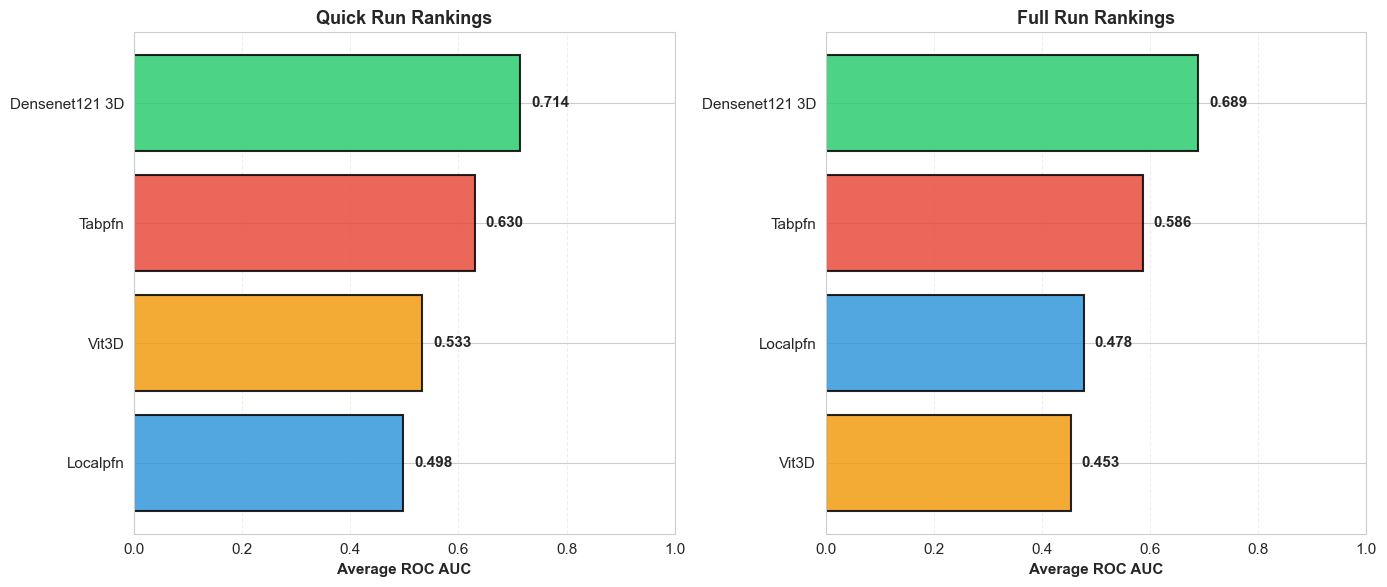

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (df_data, title) in zip(axes, [(df_quick_valid, 'Quick'), (df_full_valid, 'Full')]):
    avg = df_data.groupby('method')['roc_auc'].mean().sort_values()
    colors = [METHOD_COLORS.get(m, 'gray') for m in avg.index]
    
    ax.barh(range(len(avg)), avg.values, color=colors, edgecolor='black', linewidth=1.5, alpha=0.85)
    ax.set_yticks(range(len(avg)))
    ax.set_yticklabels([m.replace('_', ' ').title() for m in avg.index])
    ax.set_xlabel('Average ROC AUC', fontweight='bold')
    ax.set_title(f'{title} Run Rankings', fontweight='bold', fontsize=13)
    ax.set_xlim(0, 1)
    
    for i, val in enumerate(avg.values):
        ax.text(val + 0.02, i, f'{val:.3f}', va='center', fontweight='bold')
    ax.grid(axis='x', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

## Full Run Only Visualizations

In [10]:
# Prepare Full run subset
df_full_only = df_full_valid.copy()

print(f"Full run entries: {len(df_full_only)}")
df_full_only.head()

Full run entries: 20


,dataset,category,ct_name,method,accuracy,macro_f1,roc_auc,out_dir,metrics_path,pred_path,error,run
0,crlm,crlm,ct_CRLM,tabpfn,0.687500,0.686275,0.625000,/trinity/home/r112276/Med3Tab-PFN/results/expe...,/trinity/home/r112276/Med3Tab-PFN/results/expe...,/trinity/home/r112276/Med3Tab-PFN/results/expe...,NaN,Full
1,desmoid,desmoid,ct_DESMOID,tabpfn,0.634146,0.388060,0.343590,/trinity/home/r112276/Med3Tab-PFN/results/expe...,/trinity/home/r112276/Med3Tab-PFN/results/expe...,/trinity/home/r112276/Med3Tab-PFN/results/expe...,NaN,Full
2,gist,gist,ct_GIST,tabpfn,0.580000,0.578483,0.627200,/trinity/home/r112276/Med3Tab-PFN/results/expe...,/trinity/home/r112276/Med3Tab-PFN/results/expe...,/trinity/home/r112276/Med3Tab-PFN/results/expe...,NaN,Full
3,lipo,lipo,ct_LIPO,tabpfn,0.521739,0.518095,0.636364,/trinity/home/r112276/Med3Tab-PFN/results/expe...,/trinity/home/r112276/Med3Tab-PFN/results/expe...,/trinity/home/r112276/Med3Tab-PFN/results/expe...,NaN,Full
4,liver,liver,ct_LIVER,tabpfn,0.473684,0.472222,0.512465,/trinity/home/r112276/Med3Tab-PFN/results/expe...,/trinity/home/r112276/Med3Tab-PFN/results/expe...,/trinity/home/r112276/Med3Tab-PFN/results/expe...,NaN,Full


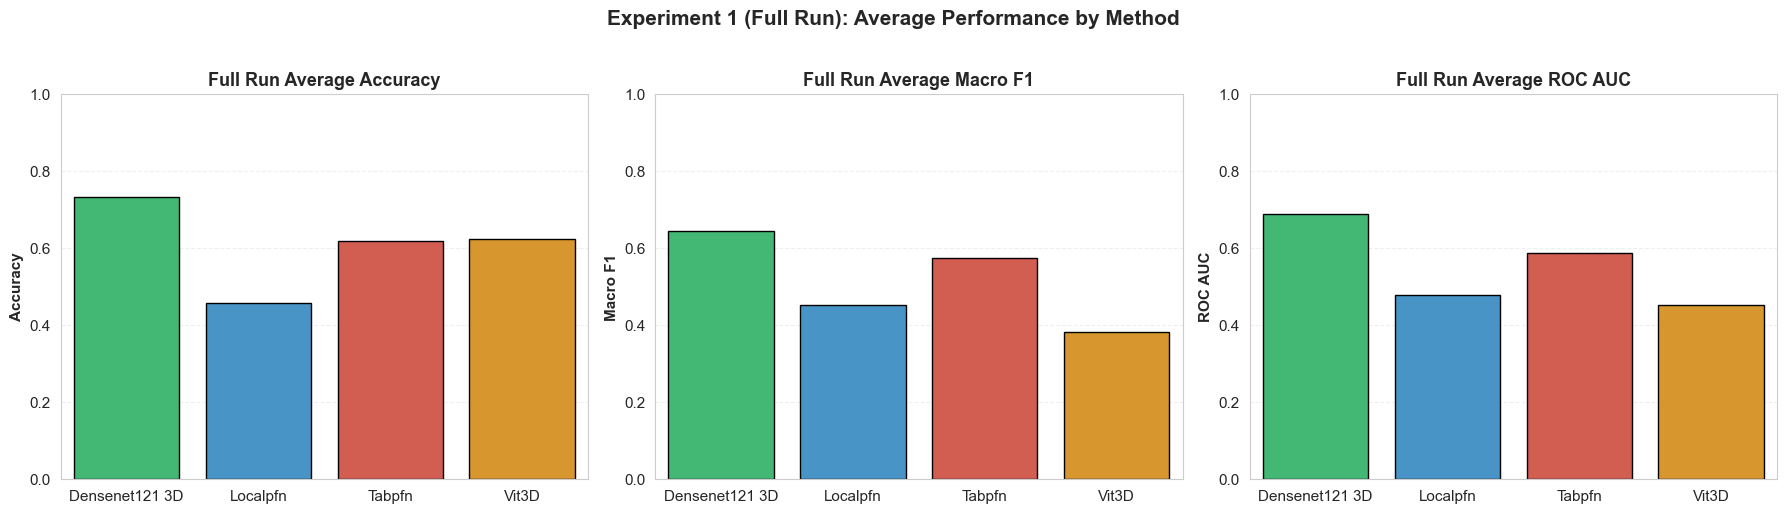

In [11]:
# 1F. Average performance by method (Full only)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (metric, name) in zip(axes, [('accuracy', 'Accuracy'), ('macro_f1', 'Macro F1'), ('roc_auc', 'ROC AUC')]):
    avg_data = (
        df_full_only.groupby('method')[metric]
        .mean()
        .reset_index()
    )

    sns.barplot(
        data=avg_data,
        x='method',
        y=metric,
        palette=METHOD_COLORS,
        ax=ax,
        edgecolor='black'
    )

    ax.set_ylabel(name, fontweight='bold')
    ax.set_title(f'Full Run Average {name}', fontweight='bold', fontsize=13)
    ax.set_xlabel('')
    ax.set_ylim(0, 1)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.set_xticklabels([m.replace('_', ' ').title() for m in avg_data['method']])

plt.suptitle('Experiment 1 (Full Run): Average Performance by Method', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

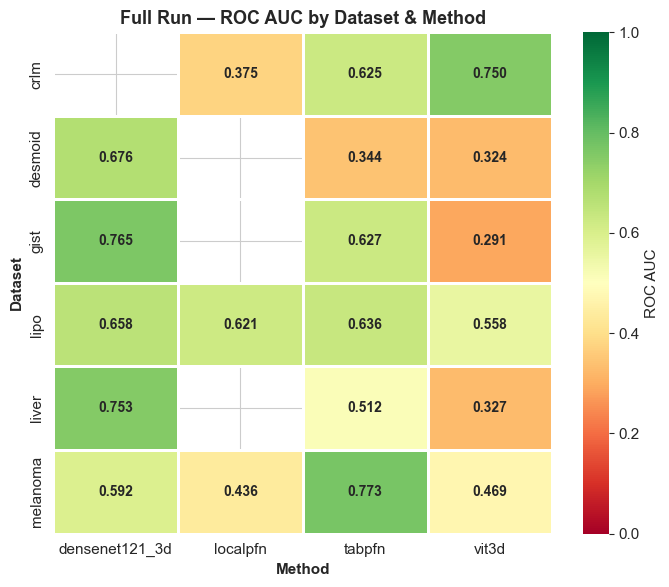

In [12]:
# 2F. ROC AUC heatmap (Full only)
fig, ax = plt.subplots(figsize=(7, 6))

pivot_full = df_full_only.pivot_table(index='dataset', columns='method', values='roc_auc')
sns.heatmap(
    pivot_full,
    annot=True,
    fmt='.3f',
    cmap='RdYlGn',
    vmin=0,
    vmax=1,
    linewidths=2,
    linecolor='white',
    cbar_kws={'label': 'ROC AUC'},
    annot_kws={'fontsize': 10, 'fontweight': 'bold'},
    ax=ax
)
ax.set_title('Full Run — ROC AUC by Dataset & Method', fontweight='bold', fontsize=13)
ax.set_xlabel('Method', fontweight='bold')
ax.set_ylabel('Dataset', fontweight='bold')
plt.tight_layout()
plt.show()

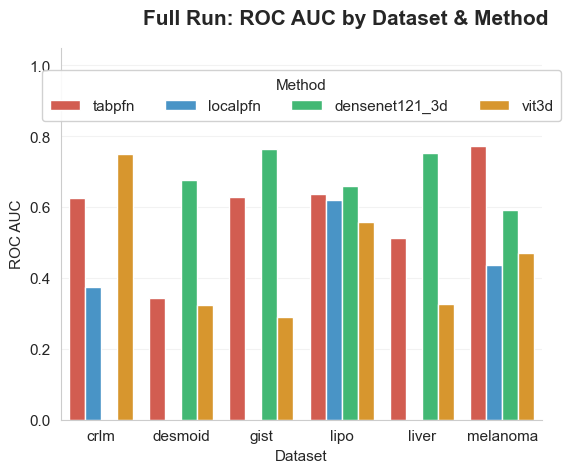

In [15]:
# 3F. Per-dataset ROC AUC bars (Full only)
dataset_order = sorted(df_full_only['dataset'].unique())
method_order = ['tabpfn', 'localpfn', 'densenet121_3d', 'vit3d']

fig = sns.catplot(
    data=df_full_only,
    x='dataset', y='roc_auc', hue='method',
    kind='bar', palette=METHOD_COLORS,
    order=dataset_order,
    hue_order=[m for m in method_order if m in df_full_only['method'].unique()],
    height=4.8, aspect=1.2
)

fig.set_axis_labels('Dataset', 'ROC AUC')
fig.fig.suptitle('Full Run: ROC AUC by Dataset & Method', fontsize=15, fontweight='bold', y=0.98)
for ax in fig.axes.flat:
    ax.set_ylim(0, 1.05)
    ax.grid(axis='y', alpha=0.25)

handles, labels = fig.axes.flatten()[0].get_legend_handles_labels()
if fig._legend is not None:
    fig._legend.remove()
fig.axes.flatten()[0].legend(
    handles,
    labels,
    title='Method',
    loc='upper center',
    bbox_to_anchor=(0.5, 0.96),
    ncol=4,
    frameon=True,
    fancybox=True,
    framealpha=0.9,
    facecolor='white',
    borderpad=0.5
)

fig.fig.subplots_adjust(top=0.9)
plt.show()

In [14]:
# 4F. Numeric summaries (Full only)
metrics_cols = ['accuracy', 'macro_f1', 'roc_auc']

full_dataset_summary = (
    df_full_only.groupby('dataset')[metrics_cols]
    .mean()
    .round(3)
)

full_method_summary = (
    df_full_only.groupby('method')[metrics_cols]
    .mean()
    .round(3)
)

print('Full run averages by dataset:')
display(full_dataset_summary)

print('\nFull run averages by method:')
display(full_method_summary)

print('\nPer-dataset breakdown (methods as rows):')
for dataset in dataset_order:
    subset = df_full_only[df_full_only['dataset'] == dataset]
    table = (
        subset.pivot_table(index='method', values=metrics_cols)
        .reindex(method_order)
        .round(3)
    )
    print(f"\nDataset: {dataset}")
    display(table)


Full run averages by dataset:


,accuracy,macro_f1,roc_auc
dataset,,,
crlm,0.562,0.482,0.583
desmoid,0.732,0.517,0.448
gist,0.573,0.518,0.561
lipo,0.630,0.551,0.619
liver,0.596,0.512,0.531
melanoma,0.643,0.508,0.568



Full run averages by method:


,accuracy,macro_f1,roc_auc
method,,,
densenet121_3d,0.733,0.644,0.689
localpfn,0.456,0.453,0.478
tabpfn,0.618,0.575,0.586
vit3d,0.625,0.382,0.453



Per-dataset breakdown (methods as rows):

Dataset: crlm


...

,accuracy,macro_f1,roc_auc
method,,,
tabpfn,0.522,0.518,0.636
localpfn,0.565,0.558,0.621
densenet121_3d,0.783,0.732,0.658
vit3d,0.652,0.395,0.558



Dataset: liver


,accuracy,macro_f1,roc_auc
method,,,
tabpfn,0.474,0.472,0.512
localpfn,NaN,NaN,NaN
densenet121_3d,0.684,0.676,0.753
vit3d,0.632,0.387,0.327



Dataset: melanoma


,accuracy,macro_f1,roc_auc
method,,,
tabpfn,0.810,0.806,0.773
localpfn,0.429,0.427,0.436
densenet121_3d,0.667,0.400,0.592
vit3d,0.667,0.400,0.469
